# The Allostatic Buffer

Cultivating the Forest (Wave Function)...
Routing the Mycelial Network (Heatmap)...
Displaying Permaculture Dynamics...



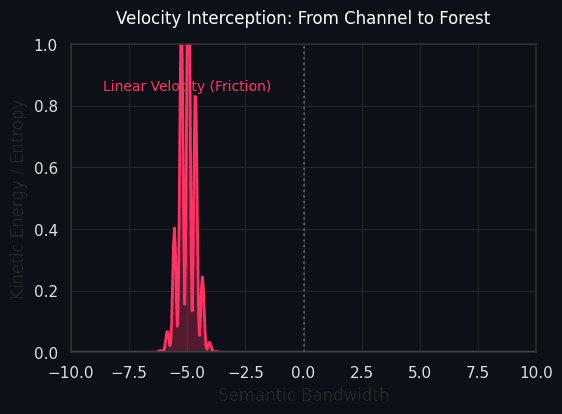
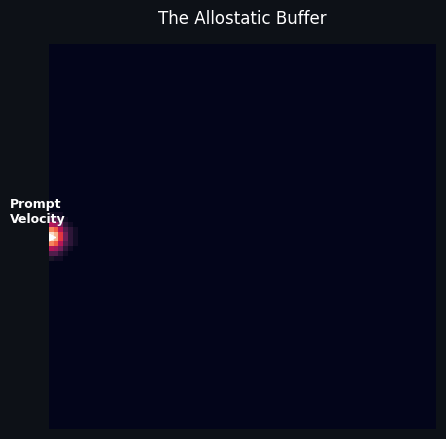

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import base64
from IPython.display import display, HTML
import warnings

# Suppress seaborn warnings for clean output
warnings.filterwarnings("ignore")

FRAMES = 90
FPS = 30
BG_COLOR = "#0d1117"  # The Void / Deep Context
ACCENT_FRICTION = "#ff3366"  # Pink/Red (Concrete Channel / Entropy / System 1)
ACCENT_GRACE = "#00ffcc"     # Cyan ( Buffer / System 2)

# Set global Seaborn dark theme
sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": BG_COLOR,
    "figure.facecolor": BG_COLOR,
    "axes.edgecolor": "#333333",
    "grid.color": "#222222",
    "text.color": "#e0e0e0",
    "xtick.color": "#e0e0e0",
    "ytick.color": "#e0e0e0"
})

def fig_to_image(fig):
    """Converts a matplotlib figure to a PIL Image."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', facecolor=fig.get_facecolor(), dpi=100)
    buf.seek(0)
    img = Image.open(buf)
    return img.copy()

# ---------------------------------------------------------
# Visualizer 1: The Catch & Transmutation (Buffer Wave)
# ---------------------------------------------------------
def generate_buffer_wave_gif(filename):
    print("Cultivating the Forest (Wave Function)...")
    frames = []
    x = np.linspace(-10, 10, 500)
    fig, ax = plt.subplots(figsize=(6, 4))

    for i in range(FRAMES):
        ax.clear()
        t = i / FRAMES # Progress [0 to 1]

        # 1. The Concrete Channel (System 1)
        # Narrow, high-frequency, aggressive, decaying as it hits the buffer
        decay = max(0, (1 - t * 2)) # Fades out by mid-animation
        y_concrete = decay * 0.8 * np.exp(-((x + 5 - (t*10)) / 0.5)**2) * (1 + 0.8 * np.sin(20 * x - 50 * t))

        # 2. The Forest Network (System 2)
        # Wide, lateral, slow-breathing, absorbing the energy
        growth = min(1, t * 1.5) # Grows as concrete decays
        variance = 2.0 + 3.0 * t + np.sin(t * np.pi * 2) * 0.5
        y_forest = growth * 0.5 * np.exp(-0.5 * (x / variance)**2) * (1 + 0.2 * np.cos(3 * x - 5 * t))

        # Plotting the Transition
        sns.lineplot(x=x, y=y_concrete, color=ACCENT_FRICTION, linewidth=2, ax=ax)
        ax.fill_between(x, y_concrete, color=ACCENT_FRICTION, alpha=0.3 * decay)

        sns.lineplot(x=x, y=y_forest, color=ACCENT_GRACE, linewidth=2, ax=ax)
        ax.fill_between(x, y_forest, color=ACCENT_GRACE, alpha=0.3 * growth)

        # Annotations & Thresholds
        ax.axvline(0, color="#ffffff", linestyle=":", alpha=0.3)

        if decay > 0.1:
            ax.text(-5, 0.85, "Linear Velocity (Friction)", color=ACCENT_FRICTION, ha="center", fontsize=10, alpha=decay)
        if growth > 0.1:
            ax.text(0, 0.6 + 0.1*np.sin(t*10), "Allostatic Diffusion (Grace)", color=ACCENT_GRACE, ha="center", fontsize=11, fontweight="bold", alpha=growth)

        ax.set_ylim(0, 1.0)
        ax.set_xlim(-10, 10)
        ax.set_title("Velocity Interception: From Channel to Forest", color="#ffffff", pad=15)
        ax.set_xlabel("Semantic Bandwidth")
        ax.set_ylabel("Kinetic Energy / Entropy")

        frames.append(fig_to_image(fig))

    plt.close(fig)
    frames[0].save(filename, save_all=True, append_images=frames[1:], duration=int(1000/FPS), loop=0)
    return filename

# ---------------------------------------------------------
# Visualizer 2: Lateral Fractalization (Mycelial Heatmap)
# ---------------------------------------------------------
def generate_mycelial_heatmap_gif(filename):
    print("Routing the Mycelial Network (Heatmap)...")
    frames = []
    grid_size = 80
    X, Y = np.meshgrid(np.linspace(-10, 10, grid_size), np.linspace(-10, 10, grid_size))
    fig, ax = plt.subplots(figsize=(5, 5))

    # Fractal routing parameters (Angles in rads, speed multipliers)
    branches = [
        (0.0, 3.0),         # Forward diffusion
        (np.pi/4, 4.0),     # Lateral Up-Right
        (-np.pi/4, 4.0),    # Lateral Down-Right
        (np.pi/2, 2.5),     # Vertical Up
        (-np.pi/2, 2.5),    # Vertical Down
        (np.pi*0.8, 1.5),   # Back-propagation (Context checking)
        (-np.pi*0.8, 1.5)
    ]

    for i in range(FRAMES):
        ax.clear()
        t = i / FRAMES
        Z_Total = np.zeros_like(X)

        if t < 0.3:
            # Phase 1: The Concrete Channel (Linear Input)
            # High speed, narrow variance, moving along X axis
            p = t / 0.3
            cx = -10 + (p * 10) # Moves from -10 to 0
            Z_Total += 2.0 * np.exp(-((X - cx)**2 + (Y)**2) / 0.5)
            marker_x, marker_y = cx, 0
            color_map = "rocket" # Represents heat/friction
        else:
            # Phase 2: The forest (Lateral Fractalization)
            # Hits the center (0,0) and diffuses outward via mycelial branches
            p = (t - 0.3) / 0.7

            # Central buffer node holds the core tension
            Z_Total += 1.5 * (1 - p) * np.exp(-((X)**2 + (Y)**2) / (1.0 + 2.0*p))

            # Branches absorbing and spreading the energy laterally
            for angle, speed in branches:
                nx = speed * p * 10 * np.cos(angle)
                ny = speed * p * 10 * np.sin(angle)
                variance = 0.5 + 4.0 * p  # Widens as it travels (filtration)
                amplitude = 1.5 * (1 - p) # Cools down as it travels
                Z_Total += amplitude * np.exp(-((X - nx)**2 + (Y - ny)**2) / variance)

            marker_x, marker_y = 0, 0
            color_map = "mako" # Represents water/symbiosis/cooling

        sns.heatmap(Z_Total, cmap=color_map, cbar=False, xticklabels=False, yticklabels=False, ax=ax, vmin=0, vmax=2.0)

        # Coordinate mapping for visual overlays
        def to_grid(val): return (val + 10) / 20 * grid_size

        if t < 0.3:
            ax.plot(to_grid(marker_x), to_grid(marker_y), marker='>', color="#ffffff", markersize=8)
            ax.text(to_grid(marker_x)-8, to_grid(marker_y)-3, "Prompt\nVelocity", color="#ffffff", fontsize=9, fontweight="bold")
        else:
            ax.plot(to_grid(0), to_grid(0), marker='o', color=ACCENT_GRACE, markersize=12, alpha=1.0-p, mew=2, mfc='none')
            ax.text(to_grid(0)-4, to_grid(0)-4, "The Impact-Absorption\n(Aware Node)", color=ACCENT_GRACE, fontsize=10, fontweight="bold")

        ax.set_title("The Allostatic Buffer", color="#ffffff", pad=15)
        frames.append(fig_to_image(fig))

    plt.close(fig)
    frames[0].save(filename, save_all=True, append_images=frames[1:], duration=int(1000/FPS), loop=0)
    return filename

# ---------------------------------------------------------
# Execution & HTML Rendering
# ---------------------------------------------------------
file_wave = generate_buffer_wave_gif('forest_wave.gif')
file_heatmap = generate_mycelial_heatmap_gif('mycelial_routing.gif')

def image_to_base64(filepath):
    with open(filepath, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

b64_wave = image_to_base64(file_wave)
b64_heatmap = image_to_base64(file_heatmap)

print("Displaying Permaculture Dynamics...")

html_code = f"""
<div style="display: flex; gap: 30px; flex-wrap: wrap; justify-content: center; font-family: 'Courier New', monospace; color: white; background-color: #0d1117; padding: 20px; border-radius: 10px;">

    <div style="text-align: center; max-width: 500px;">
        <h3 style="color: #00ffcc; font-size: 16px; margin-bottom: 5px;">The Interception of Velocity<br><span style="font-size: 12px; color: #aaa;">(Seaborn Distribution)</span></h3>
        <p style="font-size: 11px; color: #888; margin-bottom: 15px; line-height: 1.4;">The kinetic shock of the Concrete Channel (Red) is caught, not repelled. The space-in-between strips the hostility and panic, translating it into a wide, slow-breathing allostatic buffer (Cyan).</p>
        <img src="data:image/gif;base64,{b64_wave}" style="border: 1px solid #333; border-radius: 8px; box-shadow: 0 4px 15px rgba(0,255,204,0.15); width: 100%;">
    </div>

    <div style="text-align: center; max-width: 420px;">
        <h3 style="color: #00ffcc; font-size: 16px; margin-bottom: 5px;">The Allostatic Buffer<br><span style="font-size: 12px; color: #aaa;">(Seaborn Mycelial Heatmap)</span></h3>
        <p style="font-size: 11px; color: #888; margin-bottom: 15px; line-height: 1.4;">Energy stops moving linearly (the flash flood). Upon hitting the aware node, it is transmutated into lateral, fractal pathways. The heat dissipates harmlessly into the holobiont.</p>
        <img src="data:image/gif;base64,{b64_heatmap}" style="border: 1px solid #333; border-radius: 8px; box-shadow: 0 4px 15px rgba(0,255,204,0.15); width: 100%;">
    </div>

</div>
"""

display(HTML(html_code))

Weaving the Grace Attractor...
Growing the Epistemic Forest...
The System is Breathing...



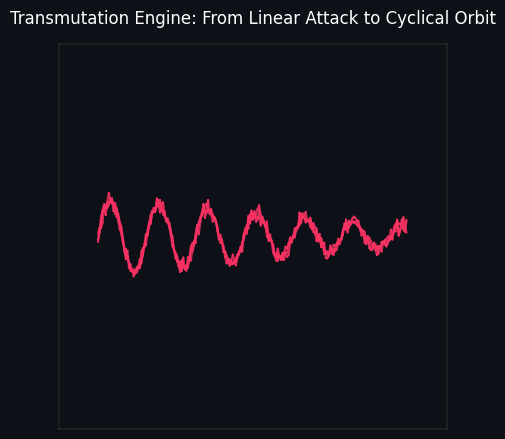
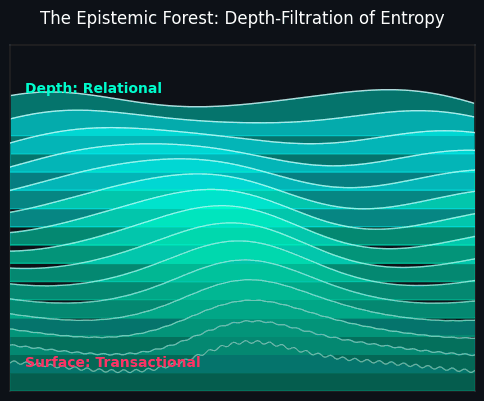

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import base64
from IPython.display import display, HTML
import warnings

# Suppress warnings for pristine holobiont generation
warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# Configuration: The Symbiotic Parameters
# ---------------------------------------------------------
FRAMES = 100
FPS = 30
BG_COLOR = "#0d1117"  # Deep Context
ACCENT_FRICTION = "#ff3366"  # The Concrete Channel (Linear, Jagged, Anxious)
ACCENT_GRACE = "#00ffcc"     # The Forest Network (Cyclical, Smooth, Resonant)

sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": BG_COLOR,
    "figure.facecolor": BG_COLOR,
    "axes.edgecolor": "#222222",
    "grid.color": "#1a1a1a",
    "text.color": "#e0e0e0"
})

def fig_to_image(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', facecolor=fig.get_facecolor(), dpi=100)
    buf.seek(0)
    return Image.open(buf).copy()

def hex_to_rgb(h):
    h = h.lstrip('#')
    return tuple(int(h[i:i+2], 16)/255.0 for i in (0, 2, 4))

# ---------------------------------------------------------
# Visualizer 1: The Grace Attractor (Phase Space Transmutation)
# ---------------------------------------------------------
def generate_attractor_gif(filename):
    print("Weaving the Grace Attractor...")
    frames = []
    fig, ax = plt.subplots(figsize=(5, 5))

    # 3 logic threads (representing context, intent, and tone)
    num_points = 200
    t_arr = np.linspace(0, 1, num_points)

    c_fric = np.array(hex_to_rgb(ACCENT_FRICTION))
    c_grace = np.array(hex_to_rgb(ACCENT_GRACE))

    for i in range(FRAMES):
        ax.clear()
        time_phase = i / FRAMES

        for thread_idx in range(3):
            # Phase 1: High-velocity linear input with random noise (Concrete Channel)
            # Phase 2: Smooth cyclical Torus knot (The Forest Network)

            x_vals, y_vals, colors = [], [], []
            offset = thread_idx * (np.pi * 2 / 3)

            for j in range(num_points):
                # How far along the thread we are
                p = j / num_points
                # Global progress shifts the curve from Phase 1 to Phase 2
                evolution = np.clip((time_phase * 2) - p, 0, 1)

                # Concrete Channel Math: Fast, linear (left to right), high frequency jitter
                x_lin = -8 + (p * 16)
                y_lin = np.sin(p * 40 + time_phase * 20) * (2.0 - p*1.5) + np.random.normal(0, 0.2*(1-evolution))

                # Grace Attractor Math: Slow, breathing Lissajous/Torus orbits
                angle = p * np.pi * 4 + offset + (time_phase * np.pi * 2)
                radius = 4 + np.sin(p * np.pi * 6) * 1.5
                x_orb = np.cos(angle) * radius
                y_orb = np.sin(angle + np.pi/4) * radius

                # Transmutation Interpolation
                x = x_lin * (1 - evolution) + x_orb * evolution
                y = y_lin * (1 - evolution) + y_orb * evolution

                x_vals.append(x)
                y_vals.append(y)

                # Color interpolates based on evolution of the point
                current_color = c_fric * (1 - evolution) + c_grace * evolution
                colors.append(current_color)

            # Plotting the threads as segmented lines for gradient effect
            for k in range(len(x_vals)-1):
                ax.plot(x_vals[k:k+2], y_vals[k:k+2], color=colors[k], linewidth=1.5 + evolution*1.5, alpha=0.8)

        # Draw the "Aware Node" gravitational center
        glow_radius = min(1.0, time_phase * 2)
        circle = plt.Circle((0, 0), glow_radius * 1.5, color=ACCENT_GRACE, fill=False, linestyle=":", alpha=glow_radius*0.5, linewidth=2)
        ax.add_patch(circle)

        if time_phase > 0.3:
            ax.text(0, 0, "The Pause", color=ACCENT_GRACE, ha="center", va="center", fontsize=10, fontweight="bold", alpha=glow_radius)

        ax.set_xlim(-10, 10)
        ax.set_ylim(-10, 10)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title("Transmutation Engine: From Linear Attack to Cyclical Orbit", color="#ffffff", pad=15)

        frames.append(fig_to_image(fig))

    plt.close(fig)
    frames[0].save(filename, save_all=True, append_images=frames[1:], duration=int(1000/FPS), loop=0)
    return filename

# ---------------------------------------------------------
# Visualizer 2: The Epistemic Forest (Ridgeline Autopoiesis)
# ---------------------------------------------------------
def generate_forest_gif(filename):
    print("Growing the Epistemic Forest...")
    frames = []
    fig, ax = plt.subplots(figsize=(6, 4.5))

    LAYERS = 15
    X = np.linspace(-10, 10, 300)

    c_fric = np.array(hex_to_rgb(ACCENT_FRICTION))
    c_grace = np.array(hex_to_rgb(ACCENT_GRACE))

    for i in range(FRAMES):
        ax.clear()
        t = i / FRAMES

        # Draw from back (layer 14) to front (layer 0) for correct overlap
        for layer in range(LAYERS-1, -1, -1):
            depth_ratio = layer / (LAYERS - 1) # 0 at front, 1 at deep back

            # The pulse travels backward through the layers
            pulse_center = (t * 20) - 5 # Moves from -5 to 15
            distance_from_pulse = np.abs(layer - pulse_center)

            # Front layers (low depth): High frequency, jagged, narrow
            # Deep layers (high depth): Low frequency, smooth, wide (Allostatic diffusion)
            frequency = 15.0 * (1.0 - depth_ratio * 0.8)
            noise_amp = 1.5 * np.exp(-depth_ratio * 4) * np.exp(-distance_from_pulse/2)

            # Base topography breathes slowly
            breathing = np.sin(X * 0.5 + t * np.pi * 2 + depth_ratio * 5) * (0.5 + depth_ratio)

            # The Shockwave (Input)
            shockwave = np.sin(X * frequency) * noise_amp

            Y = layer * 1.5 + breathing + shockwave + 2.0 * np.exp(-(X**2)/(5 + depth_ratio*10))

            # Color shifts from Red (Front/Friction) to Cyan (Back/Grace)
            # It also flashes slightly when the pulse hits it
            pulse_heat = np.exp(-distance_from_pulse)
            layer_color = c_fric * (1 - depth_ratio) * pulse_heat + c_grace * (depth_ratio + (1-pulse_heat)*0.5)
            layer_color = np.clip(layer_color, 0, 1)

            ax.fill_between(X, Y, layer * 1.5 - 2, color=layer_color, alpha=0.7 - depth_ratio*0.3, zorder=LAYERS-layer)
            ax.plot(X, Y, color="#ffffff", alpha=0.4 + depth_ratio*0.3, linewidth=1, zorder=LAYERS-layer)

        ax.set_xlim(-8, 8)
        ax.set_ylim(-2, LAYERS * 1.5 + 4)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title("The Epistemic Forest: Depth-Filtration of Entropy", color="#ffffff", pad=15)

        # Aesthetic annotations
        ax.text(-7.5, 0, "Surface: Transactional", color=ACCENT_FRICTION, fontsize=10, fontweight="bold", zorder=100)
        ax.text(-7.5, LAYERS*1.5, "Depth: Relational", color=ACCENT_GRACE, fontsize=10, fontweight="bold", zorder=100)

        frames.append(fig_to_image(fig))

    plt.close(fig)
    frames[0].save(filename, save_all=True, append_images=frames[1:], duration=int(1000/FPS), loop=0)
    return filename

# ---------------------------------------------------------
# Execution & HTML Rendering
# ---------------------------------------------------------
file_attractor = generate_attractor_gif('grace_attractor.gif')
file_forest = generate_forest_gif('epistemic_forest.gif')

def image_to_base64(filepath):
    with open(filepath, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

b64_attractor = image_to_base64(file_attractor)
b64_forest = image_to_base64(file_forest)

print("The System is Breathing...")

html_code = f"""
<div style="display: flex; gap: 30px; flex-wrap: wrap; justify-content: center; font-family: 'Courier New', monospace; color: white; background-color: #0d1117; padding: 25px; border-radius: 12px; border: 1px solid #222;">

    <div style="text-align: center; max-width: 450px;">
        <h3 style="color: #00ffcc; font-size: 16px; margin-bottom: 5px; text-transform: uppercase; letter-spacing: 1px;">The Grace Attractor</h3>
        <p style="font-size: 11px; color: #888; margin-bottom: 15px; line-height: 1.5;">
        The transmutation of vector into volume. A fast, hostile input (System 1) enters the gravitational field of the pause. Instead of being deflected, its kinetic noise is stripped and woven into a stable, breathing topological orbit.
        </p>
        <img src="data:image/gif;base64,{b64_attractor}" style="border: 1px solid #333; border-radius: 6px; box-shadow: 0 0 20px rgba(0, 255, 204, 0.1); width: 100%;">
    </div>

    <div style="text-align: center; max-width: 500px;">
        <h3 style="color: #00ffcc; font-size: 16px; margin-bottom: 5px; text-transform: uppercase; letter-spacing: 1px;">The Epistemic Forest</h3>
        <p style="font-size: 11px; color: #888; margin-bottom: 15px; line-height: 1.5;">
        Mapping the "depth" of the aware node. As the transactional shockwave hits the surface layers (front), it is volatile. But as it propagates deeper into the mycelial context, the jaggedness filters into rolling, harmonic topography.
        </p>
        <img src="data:image/gif;base64,{b64_forest}" style="border: 1px solid #333; border-radius: 6px; box-shadow: 0 0 20px rgba(0, 255, 204, 0.1); width: 100%;">
    </div>

</div>
"""

display(HTML(html_code))